# ガウス混合モデルにおける推論

## 準備

In [6]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 利用可能なフォント一覧を取得
available_fonts = [f.name for f in fm.fontManager.ttflist]
print("利用可能なフォント一覧:")
print(available_fonts)

# 優先フォント設定
font_families = []

if "Yu Gothic" in available_fonts:
    font_families.append("Yu Gothic")  # Windows向け日本語
    print("日本語フォント: Yu Gothic を使用します")
elif "Noto Sans CJK JP" in available_fonts:
    font_families.append("Noto Sans CJK JP")  # Linux向け日本語
    print("日本語フォント: Noto Sans CJK JP を使用します")
else:
    print("日本語フォントが見つかりません．")
    print("結果画像内の日本語が豆腐になる可能性があります")

# 欧文用フォントを追加（必ずカバーしておきたい）
font_families.append("DejaVu Sans")

# matplotlib に適用
plt.rcParams["font.family"] = font_families
print("最終的に使用するフォント順:", plt.rcParams["font.family"])


利用可能なフォント一覧:
['STIXSizeThreeSym', 'DejaVu Sans Mono', 'cmsy10', 'DejaVu Serif', 'cmss10', 'DejaVu Serif', 'cmex10', 'cmr10', 'DejaVu Sans', 'STIXSizeThreeSym', 'DejaVu Serif', 'DejaVu Sans', 'cmmi10', 'STIXGeneral', 'cmtt10', 'STIXNonUnicode', 'DejaVu Sans', 'STIXSizeTwoSym', 'DejaVu Sans', 'STIXGeneral', 'STIXSizeOneSym', 'DejaVu Sans Mono', 'STIXSizeFourSym', 'STIXNonUnicode', 'STIXNonUnicode', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Sans Mono', 'STIXSizeFourSym', 'STIXGeneral', 'STIXSizeFiveSym', 'STIXSizeTwoSym', 'DejaVu Serif Display', 'cmb10', 'STIXNonUnicode', 'STIXGeneral', 'STIXSizeOneSym', 'Ubuntu', 'Ubuntu', 'Ubuntu Sans', 'Ubuntu Sans', 'Ubuntu', 'DejaVu Serif', 'Ubuntu Mono', 'Ubuntu', 'Ubuntu Mono', 'Ubuntu', 'Noto Sans CJK JP', 'DejaVu Sans', 'Ubuntu', 'Ubuntu Mono', 'Ubuntu Mono', 'DejaVu Sans Mono', 'Ubuntu', 'Ubuntu Sans Mono', 'Noto Serif CJK JP', 'DejaVu Sans Mono', 'Noto Sans CJK JP', 'Ubuntu', 'Noto Serif CJK JP', 'Ubuntu Mono', 'DejaVu 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


def plot_ellipse(ax, mean, cov, color, label, sigma_scale=2):
    """
    指定された平均と共分散を持つガウス分布の信頼区間楕円を描画する関数

    Args:
        ax (matplotlib.axes.Axes): 描画対象のAxesオブジェクト
        mean (np.ndarray): 分布の平均 (2次元)
        cov (np.ndarray): 分布の共分散行列 (2x2)
        color (str): 楕円の色
        label (str): 凡例のラベル
        sigma_scale (int): 何シグマ区間を描画するか (例: 2 for 2σ)
    """
    # 共分散行列の固有値と固有ベクトルを計算
    # 固有値が楕円の軸の長さの2乗、固有ベクトルが楕円の軸の方向に対応する
    eigvals, eigvecs = np.linalg.eigh(cov)

    # 固有ベクトルの最初のベクトルから角度を計算
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    # 固有値から楕円の幅と高さを計算
    # 固有値は分散なので、平方根を取って標準偏差にする
    width, height = 2 * sigma_scale * np.sqrt(eigvals)

    # 楕円のパッチを作成
    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=color,
        fc="None",
        lw=2,
        label=label,
    )

    # Axesにパッチを追加
    ax.add_patch(ellipse)

## シナリオ設定

機械学習のアルゴリズムを試す際によく使われる、アヤメの品種分類問題のように、データがいくつかの明確なグループ（クラスタ）に分かれている状況を想定します。

  * **クラスタ数 (K)**: 3
  * **データ数 (N)**: 500
  * **次元数 (D)**: 2
  * **真の混合比率 ($\boldsymbol{\pi}$)**: 3つのクラスタから、それぞれ 50%, 30%, 20% の割合でデータが生成されるとします。
      * $\boldsymbol{\pi} = [0.5, 0.3, 0.2]$
  * **真の平均 ($\boldsymbol{\mu}$)**: 3つのクラスタが2次元平面上で離れた位置に中心を持つように設定します。
      * $\boldsymbol{\mu}_1 = [0, 5]$
      * $\boldsymbol{\mu}_2 = [-5, -5]$
      * $\boldsymbol{\mu}_3 = [5, -5]$
  * **真の共分散行列 ($\boldsymbol{\Sigma}$)**: 各クラスタが異なる形状と向きを持つように、共分散行列を設定します。これにより、より現実的で面白い問題設定になります。（ギブスサンプリングでは精度行列 $\boldsymbol{\Lambda} = \boldsymbol{\Sigma}^{-1}$ を用いますが、データ生成時は共分散行列の方が直感的です。）
      * **クラスタ1**: 標準的な円形の分布
        $\boldsymbol{\Sigma}_1 = \begin{pmatrix} 3 & 0 \\ 0 & 3 \end{pmatrix}$
      * **クラスタ2**: 斜めに長く伸びた楕円形の分布
        $\boldsymbol{\Sigma}_2 = \begin{pmatrix} 4 & 2.5 \\ 2.5 & 2 \end{pmatrix}$
      * **クラスタ3**: 横に広い楕円形の分布
        $\boldsymbol{\Sigma}_3 = \begin{pmatrix} 5 & -2 \\ -2 & 2 \end{pmatrix}$

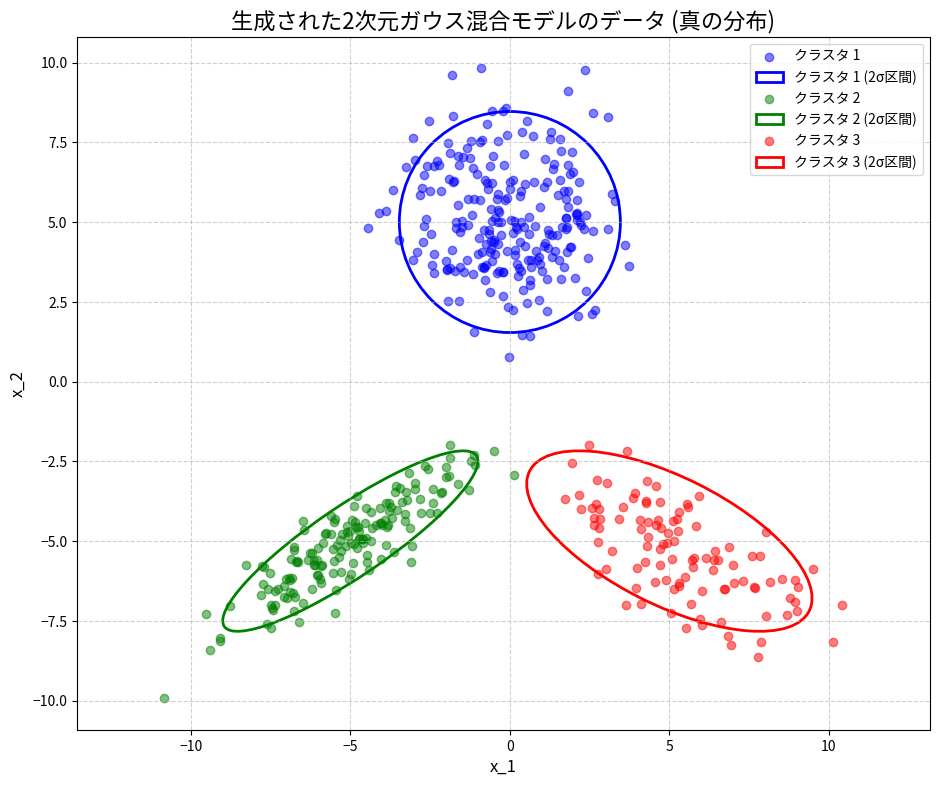

In [ ]:
# 1. シナリオ設定
# --------------------------------------------------
# 真のパラメータ
K = 3  # クラスタ数
N = 500  # データ数
D = 2  # 次元数

# 混合比率
true_pi = np.array([0.5, 0.3, 0.2])

# 平均
true_mu = np.array([[0.0, 5.0], [-5.0, -5.0], [5.0, -5.0]])

# 共分散行列
true_sigma = np.array(
    [
        [
            [3.0, 0.0],
            [0.0, 3.0],
        ],
        [
            [4.0, 2.5],
            [2.5, 2.0],
        ],
        [
            [5.0, -2.0],
            [-2.0, 2.0],
        ],
    ]
)


# 2. データの生成
# --------------------------------------------------
# 潜在変数 S (各データがどのクラスタに属するか) を生成
true_s = np.random.choice(np.arange(K), p=true_pi, size=N)

# 観測データ X を格納する配列
X = np.zeros((N, D))

# 各データを対応するガウス分布からサンプリング
for n in range(N):
    k = true_s[n]  # データnが属するクラスタ
    X[n] = np.random.multivariate_normal(mean=true_mu[k], cov=true_sigma[k])


# 3. データの可視化
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 9))

colors = ["blue", "green", "red"]
scatter_labels = ["クラスタ 1", "クラスタ 2", "クラスタ 3"]
ellipse_labels = ["クラスタ 1 (2σ区間)", "クラスタ 2 (2σ区間)", "クラスタ 3 (2σ区間)"]


for k in range(K):
    # k番目のクラスタに属するデータだけを抽出
    cluster_data = X[true_s == k]
    # 散布図をプロット
    ax.scatter(
        cluster_data[:, 0],
        cluster_data[:, 1],
        color=colors[k],
        alpha=0.5,
        label=scatter_labels[k],
    )
    # 2シグマ区間の楕円をプロット
    plot_ellipse(ax, true_mu[k], true_sigma[k], colors[k], ellipse_labels[k])


ax.set_title("生成された2次元ガウス混合モデルのデータ (真の分布)", fontsize=16)
ax.set_xlabel("x_1", fontsize=12)
ax.set_ylabel("x_2", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
ax.axis("equal")  # 軸のスケールを揃える
plt.show()


## 対数尤度の計算

### 多変量ガウス密度

観測ベクトル $x_n \in \mathbb{R}^D$ に対するクラスタ $k$ の多変量ガウス密度は

$$
\mathcal{N}(x_n \mid \mu_k, \Sigma_k)
= \frac{1}{(2\pi)^{D/2}|\Sigma_k|^{1/2}}
\exp\left(-\tfrac{1}{2}(x_n-\mu_k)^\top \Sigma_k^{-1}(x_n-\mu_k)\right).
$$


### 1点の尤度（混合）

混合係数を $\pi_k$（$\sum_{k=1}^K\pi_k=1,\ \pi_k\ge0$）とすると、データ点 $x_n$ の尤度は

$$
p(x_n \mid \pi, \mu, \Sigma)
= \sum_{k=1}^{K}\pi_k\,\mathcal{N}(x_n \mid \mu_k, \Sigma_k).
$$


### データ集合全体の尤度

独立同分布を仮定するとデータ集合 $X=\{x_1,\dots,x_N\}$ の尤度は

$$
L(\pi, \mu, \Sigma \mid X)
= \prod_{n=1}^{N} p(x_n \mid \pi, \mu, \Sigma)
= \prod_{n=1}^{N}\left(\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x_n \mid \mu_k, \Sigma_k)\right).
$$


### 対数尤度（最終式）

数値安定性のために対数を取ると

$$
\ell(\pi, \mu, \Sigma \mid X)
= \log L(\pi, \mu, \Sigma \mid X)
= \sum_{n=1}^{N} \log\!\left(\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x_n \mid \mu_k, \Sigma_k)\right).
$$


---

### 数値安定化（実装上の注意）

上の式をそのまま計算すると小さい値の掛け算でアンダーフローするので、**対数空間で計算して log-sum-exp を使う**のが普通です。すなわち各 $k$ について

$$
\log \big(\pi_k\,\mathcal{N}(x_n \mid \mu_k, \Sigma_k)\big)
= \log\pi_k + \log\mathcal{N}(x_n \mid \mu_k, \Sigma_k),
$$

を計算し、

$$
\log\Big(\sum_k \pi_k\,\mathcal{N}(\cdot)\Big)
= \operatorname{logsumexp}_k\big(\log\pi_k + \log\mathcal{N}(\cdot)\big).
$$

`logsumexp(a_k)` は数値的に安定な方法で $\log\sum_k e^{a_k}$ を返します。


In [ ]:
from scipy.stats import multivariate_normal
from scipy.special import logsumexp


# --- 対数尤度を計算するヘルパー関数 (GMM版) ---
def calculate_log_likelihood_gmm(
    X: np.ndarray,  # 観測データ (N, D)
    pi: np.ndarray,  # 混合比率 (K,)
    mu: np.ndarray,  # 平均 (K, D)
    sigma: np.ndarray,  # 共分散行列 (K, D, D)
) -> float:
    """
    与えられたパラメータで、GMMの対数尤度を計算する。

    Log-Likelihood = Σ_n log( Σ_k pi_k * N(x_n | mu_k, sigma_k) )
    """
    N, D = X.shape
    K = len(pi)

    log_pi = np.log(pi + 1e-16)  # 0除算防止
    log_prob = np.zeros((N, K))

    # 各データnと各クラスタkの組み合わせに対して、重み付きの確率密度を計算
    for k in range(K):
        try:
            # log(π_k) + log N(x|μ_k,Σ_k)
            log_pdf = multivariate_normal.logpdf(X, mean=mu[k], cov=sigma[k]) # N個のデータをまとめて計算
            log_prob[:, k] = log_pi[k] + log_pdf
        except np.linalg.LinAlgError:
            # 正定値化して再計算
            sigma_reg = sigma[k] + 1e-6 * np.eye(D)
            log_pdf = multivariate_normal.logpdf(X, mean=mu[k], cov=sigma_reg)
            log_prob[:, k] = log_pi[k] + log_pdf

    # log-sum-exp で数値安定化
    log_likelihood = np.sum(logsumexp(log_prob, axis=1))
    return float(log_likelihood)


## ギブスサンプリング